In [4]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import matplotlib.cm as cm

from protocols import utils, functions

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Entire dataset

We want to release a catalogue built on the entire dataset, and therefore need to run a gridsearch also on the entire dataset.

Code mostly the same as `02-grid-search.ipynb`

In [9]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.3.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 8

In [10]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    train_phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=False)
    val_phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=True)
    
    #combine training and validation samples into one dataset
    phenotypes = pd.concat([train_phenotypes, val_phenotypes])

    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]: #PWF: only one p-value for now, removed 0.95
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [13]:
if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.3.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.csv.gz",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/cryptic-v3.3.0/all-samples/grid_search",
      0.1,
      'v3.3.0',
      'v3.3.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/all-samples/grid_results_v3.3.0.csv')

else: 
   
   df = pd.read_csv('results/grid_search/all-samples/grid_results_v3.3.0.csv')

df[:10]

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,0,0.0,AMI,0.05,0.90,0.857650,0.983952,0.927230,0.836505,0.985189
1,1,1.0,AMI,0.05,0.95,0.857523,0.984035,0.927088,0.835640,0.985266
2,2,2.0,AMI,0.10,0.90,0.842888,0.984582,0.958290,0.833045,0.985266
3,3,3.0,AMI,0.10,0.95,0.842888,0.984562,0.957155,0.833045,0.985266
4,4,4.0,AMI,0.15,0.90,0.841667,0.985346,0.962692,0.830017,0.985924
5,5,5.0,AMI,0.15,0.95,0.842036,0.985298,0.959746,0.830017,0.985924
6,6,6.0,AMI,0.20,0.90,0.841667,0.985354,0.963154,0.830017,0.985924
7,7,7.0,AMI,0.20,0.95,0.841667,0.985346,0.962692,0.830017,0.985924
8,8,8.0,AMI,0.25,0.90,0.840929,0.985406,0.966384,0.830017,0.985924
9,9,9.0,AMI,0.25,0.95,0.841667,0.985361,0.963580,0.830017,0.985924


In [14]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)
melted_df

,DRUG,BACKGROUND_RATE,p_value,Metric,value
0,AMI,0.05,0.90,SENSITIVITY,85.764967
1,AMI,0.05,0.95,SENSITIVITY,85.752330
2,AMI,0.10,0.90,SENSITIVITY,84.288840
3,AMI,0.10,0.95,SENSITIVITY,84.288840
4,AMI,0.15,0.90,SENSITIVITY,84.166667
...,...,...,...,...,...
535,MXF,0.15,0.95,DPR,92.910999
536,MXF,0.20,0.90,DPR,93.592998
537,MXF,0.20,0.95,DPR,93.543743
538,MXF,0.25,0.90,DPR,93.987042


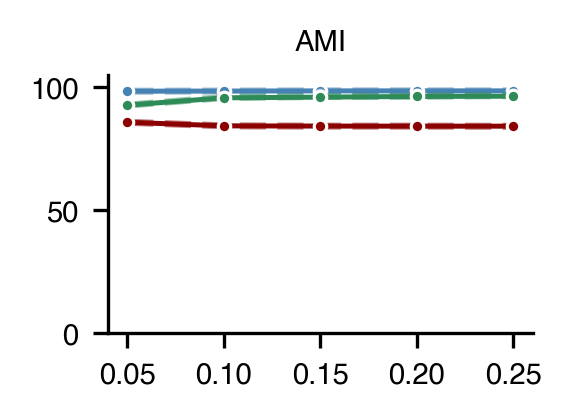

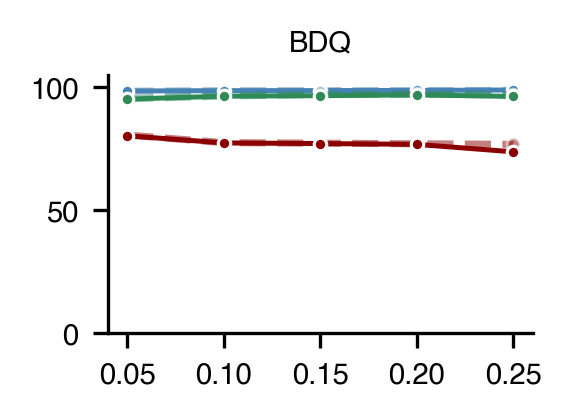

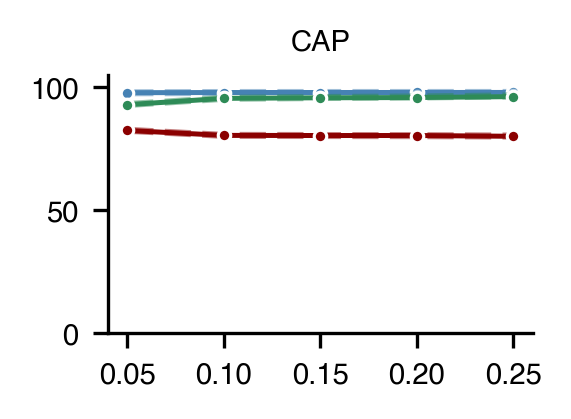

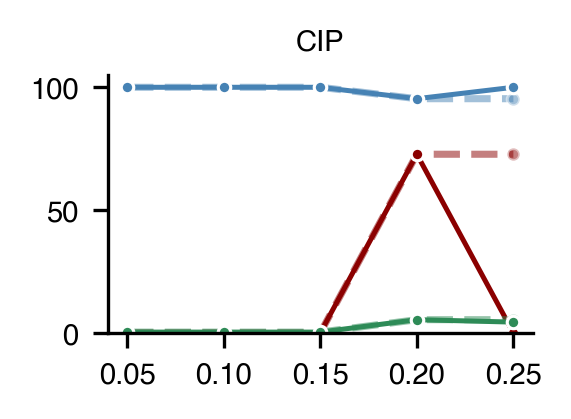

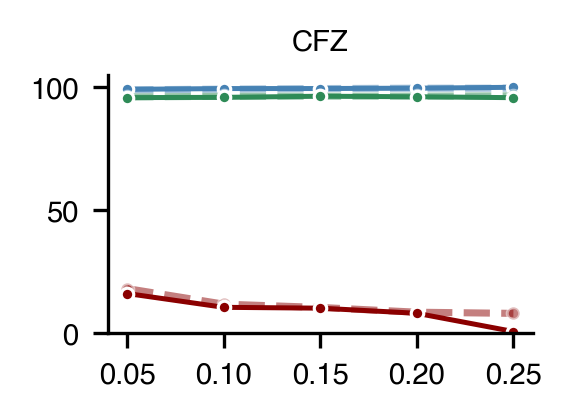

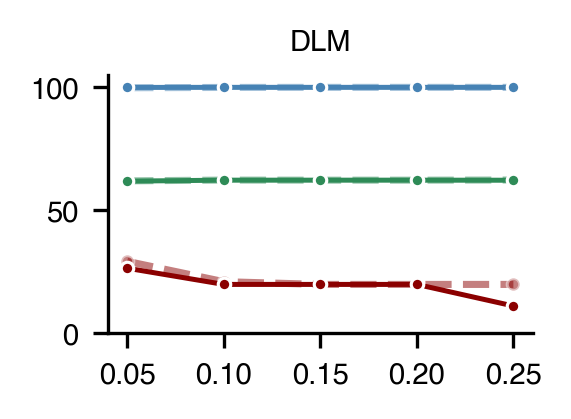

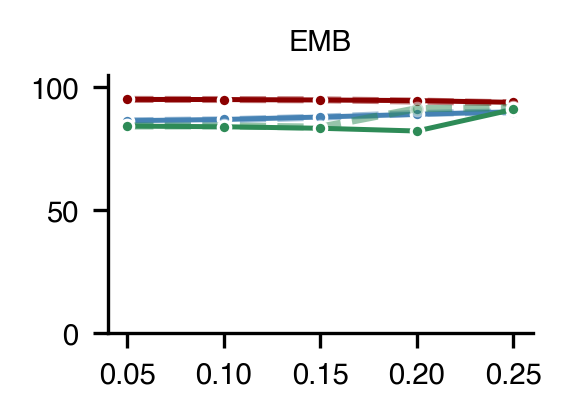

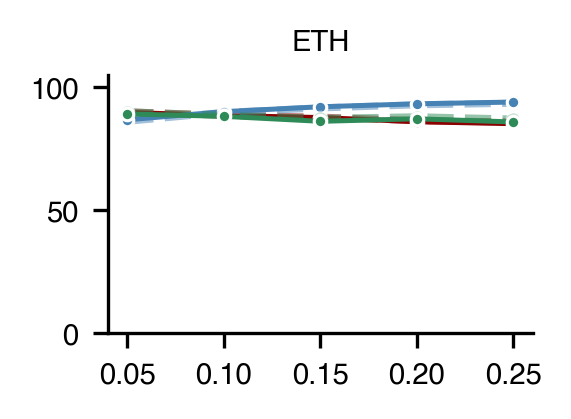

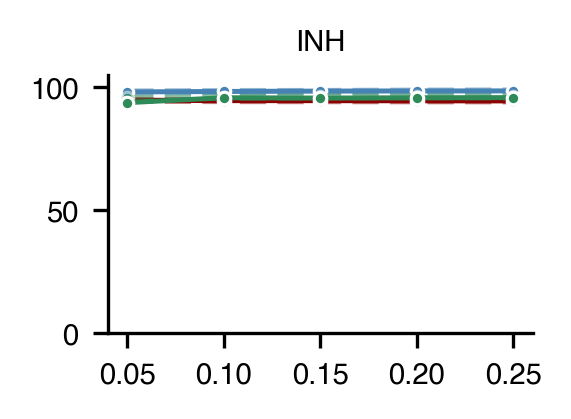

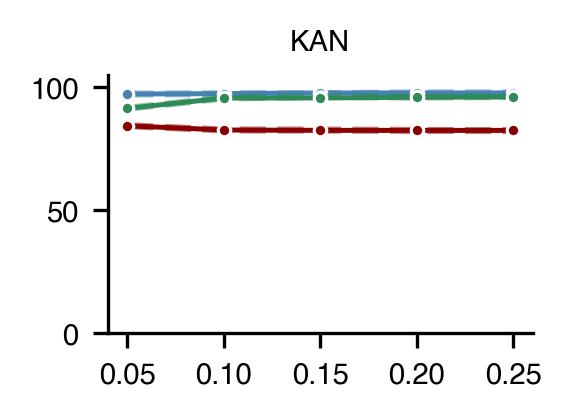

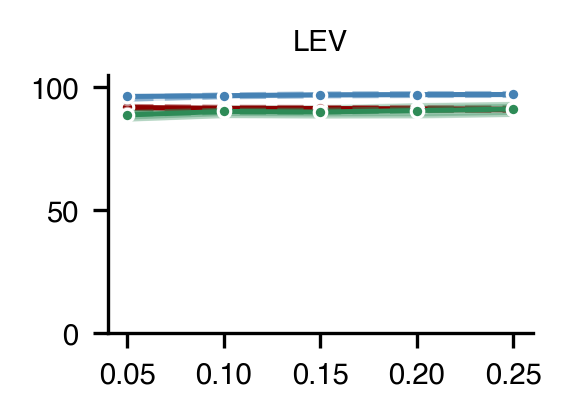

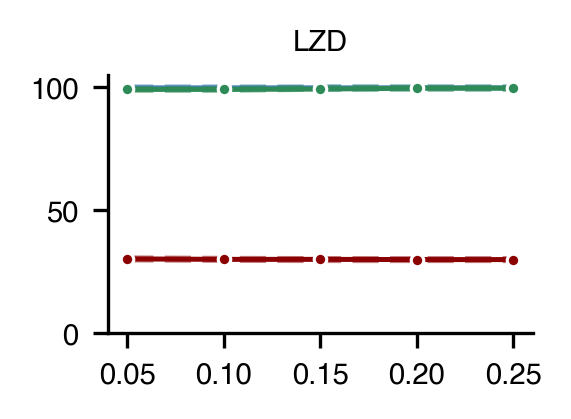

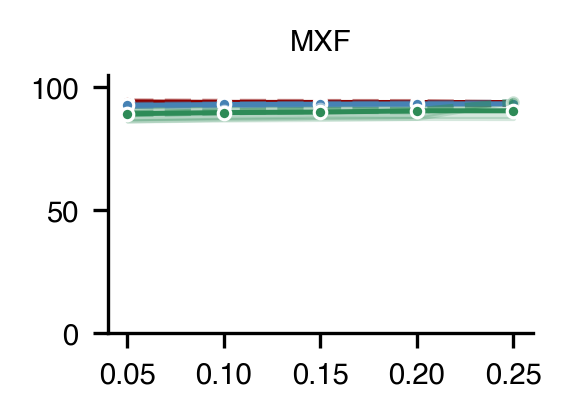

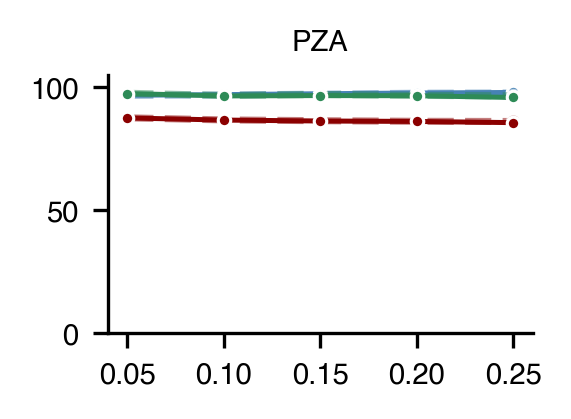

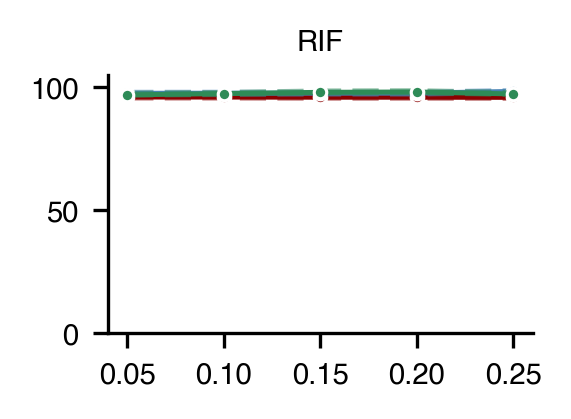

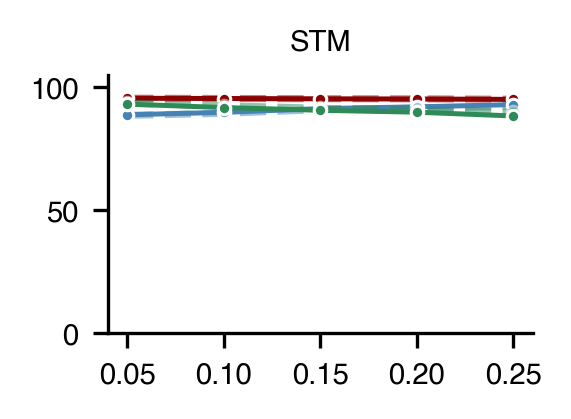

In [15]:

metric_colors = {
    "SENSITIVITY": "#8B0000",  # dark red
    "SPECIFICITY": "#4682B4",  # steel blue
    "DPR": "#2E8B57"           # sea green
}
for drug in melted_df["DRUG"].unique():
    drug_data = melted_df[melted_df["DRUG"] == drug]

    plt.figure(figsize=(2, 1.5))

    for metric in drug_data["Metric"].unique():
        for p in drug_data["p_value"].unique():
            subset = drug_data[
                (drug_data["Metric"] == metric) &
                (drug_data["p_value"] == p)
            ]
            sns.lineplot(
                data=subset,
                x="BACKGROUND_RATE",
                y="value",
                color=metric_colors[metric],
                alpha=0.5 if p == 0.90 else 1.0,  # Example: faded for 0.90, solid for 0.95
                marker="o",
                linestyle="--" if p == 0.90 else "-",  # Dashed for 0.90
                markersize=3,
                linewidth=1.7 if p == 0.9 else 1.2
            )

    plt.title(drug, fontsize=7)
    plt.xlabel("")
    plt.ylabel("")  # No y-label
    plt.ylim(0, 105)
    plt.tick_params(labelsize=7)
    sns.despine(top=True, right=True)
    plt.xticks(np.arange(0.05, 0.26, 0.05))  

    plt.tight_layout()
    #plt.savefig(f'figs/grid_search/{drug}.pdf', transparent=True)

    plt.show()
    plt.close()


In [16]:
#determine the best performing catalogue
opt_cats_v1 = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

#pull out R, S, U counts from catalogue
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats_v1['DRUG'][i],
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    }
    for i in opt_cats_v1.index
    for cat in [pd.read_csv(f"./catalogues/cryptic-v3.3.0/all-samples/grid_search/{opt_cats_v1['DRUG'][i].lower()}/bg_{opt_cats_v1['BACKGROUND_RATE'][i]}_p_{opt_cats_v1['p_value'][i]}_FRS_0.1.csv")]
])

opt_cats_v1 = pd.merge(opt_cats_v1, cat_counts, on='DRUG')
opt_cats_v1['catalogue'] = 'catomatic_v3.3.0_all_samples'
opt_cats_v1.to_csv('results/grid_search/all-samples/opt_cats_v3.3.0.csv',index=False)
opt_cats_v1

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,148,148.0,RIF,0.25,0.90,0.959023,0.983060,0.974454,0.941918,0.983552,0.969320,47,26,400,473,catomatic_v3.3.0_all_samples
1,86,86.0,INH,0.20,0.90,0.945069,0.984559,0.961306,0.925400,0.985334,0.960164,88,25,731,844,catomatic_v3.3.0_all_samples
2,18,NaN,MXF,0.25,0.90,0.933741,0.935386,0.939870,0.906016,0.939609,0.935460,12,35,653,700,catomatic_v3.3.0_all_samples
3,154,154.0,STM,0.15,0.90,0.953480,0.909160,0.914384,0.903127,0.918497,0.932365,135,12,628,775,catomatic_v3.3.0_all_samples
4,8,NaN,LEV,0.25,0.90,0.906216,0.971491,0.934516,0.870765,0.973515,0.931459,14,25,434,473,catomatic_v3.3.0_all_samples
5,130,130.0,PZA,0.05,0.90,0.875633,0.966762,0.975638,0.866854,0.967671,0.922973,554,1,170,725,catomatic_v3.3.0_all_samples
6,66,66.0,EMB,0.20,0.90,0.943936,0.893224,0.912993,0.895825,0.903340,0.922534,23,46,1197,1266,catomatic_v3.3.0_all_samples
7,0,0.0,AMI,0.05,0.90,0.857650,0.983952,0.927230,0.836505,0.985189,0.909456,12,8,491,511,catomatic_v3.3.0_all_samples
8,94,94.0,KAN,0.15,0.90,0.825698,0.974336,0.962310,0.816059,0.975381,0.897612,10,16,498,524,catomatic_v3.3.0_all_samples
9,20,20.0,CAP,0.05,0.90,0.824950,0.977598,0.929635,0.793037,0.979243,0.891681,63,4,317,384,catomatic_v3.3.0_all_samples


In [17]:
rows = []

for idx,row in opt_cats_v1.iterrows():
    cat_path = pathlib.Path( "./catalogues/cryptic-v3.3.0/all-samples/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{row.p_value}_FRS_0.1.csv"
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'catomatic_v3.3.0_all_samples'
cat.CATALOGUE_VERSION = '0.1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/catomatic_v3.3.0_all_samples.csv',index=False)
cat


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.01069402007856831, ""confidenc...",{}
1,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [-3.33282421...",{}
2,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1372...",{}
3,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,RIF,rpoB@E563D,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.2129...",{}
4,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.050505050505050504, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
157,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,DLM,ddn@*?,U,{},"{""default_rule"": ""True""}",{}
158,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,DLM,ddn@-*?,U,{},"{""default_rule"": ""True""}",{}
159,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,DLM,ddn@*_indel,U,{},"{""default_rule"": ""True""}",{}
160,NC00962.3,catomatic_v3.3.0_all_samples,0.1,GARC1,RUS,DLM,ddn@-*_indel,U,{},"{""default_rule"": ""True""}",{}
